In [1]:
import re
import sys
from pathlib import Path
from typing import Any, Tuple

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
import seaborn as sns

# Ensure project root is in path
PROJECT_ROOT = Path(__file__).resolve().parent.parent if "__file__" in globals() else Path(".").resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from notebooks.visualization_utils import add_baseline_guide, plot_performance_distribution
from src.data_utils import DatasetPT
from src.graph_analysis import calculate_moments_error, calculate_annd_error

# --- Shared Caching Utilities ---
_DEGREE_CACHE = {}

def get_degree_sequence(dataset_path: str | Path, idx: int) -> np.ndarray | None:
    """Retrieves the degree sequence for a specific graph in a PyG dataset.
    
    Results are cached per dataset_path to avoid redundant torch.load calls.
    """
    path = Path(dataset_path)
    if path not in _DEGREE_CACHE:
        if not path.exists():
            _DEGREE_CACHE[path] = None
        else:
            try:
                # Use the robust DatasetPT loader to handle collated PyG datasets
                dataset = DatasetPT(path)
                seqs = []
                for i in range(len(dataset)):
                    data = dataset[i]
                    row = data.edge_index[0]
                    # num_nodes is reliably inferred by DatasetPT/Batch
                    n = data.num_nodes
                    deg = np.zeros(n, dtype=int)
                    if row.numel() > 0:
                        np.add.at(deg, row.numpy(), 1)
                    seqs.append(deg)
                _DEGREE_CACHE[path] = seqs
            except Exception as e:
                print(f"Error loading {path}: {e}")
                _DEGREE_CACHE[path] = None
                
    ds_seqs = _DEGREE_CACHE[path]
    if ds_seqs and 0 <= idx < len(ds_seqs):
        return ds_seqs[idx]
    return None

In [ ]:
RESULTS_DIR = PROJECT_ROOT / "results"
DATASET_NAMES = [
        "MUTAG",
    ]
BASE_METHOD_ORDER = ["dummyNodes", "dummyEdges", "padma", "anndg"]
PALETTE = {
    "original": "#5B9BD5", 
    "padma": "#F5C431", 
    "anndg": "#E06C75",
    "pdd": "#5CE9FF", 
    "dummyEdges": "#98C379", 
    "dummyNodes": "#DA7CF7"}

def load_experiment_data() -> Tuple[pd.DataFrame, pd.DataFrame]:
    """Loads and preprocesses main GNN evaluation data and per-graph statistics."""
    dfs_results = []
    results_pattern = re.compile(r"gnn_eval_(?P<dname>.+)_(?P<mname>.+)\.csv")
    for csv_path in RESULTS_DIR.glob("gnn_eval_*.csv"):
        match = results_pattern.match(csv_path.name)
        if match and match.group("dname") in DATASET_NAMES:
            dfs_results.append(pd.read_csv(csv_path))

    if not dfs_results:
        raise FileNotFoundError(f"No results found in {RESULTS_DIR} for datasets: {DATASET_NAMES}.")

    df_raw = pd.concat(dfs_results, ignore_index=True)
    for col in ["val_best_f1", "test_f1", "test_acc", "test_roc_auc"]:
        df_raw[col] = pd.to_numeric(df_raw[col], errors="coerce")

    df_raw["source_base"] = df_raw["source"].apply(lambda s: s.rsplit("_", 1)[0] if s != "original" else s)

    all_found = set(df_raw["source_base"]) - {"original"}
    ordered_m = [m for m in BASE_METHOD_ORDER if m in all_found] + sorted([m for m in all_found if m not in BASE_METHOD_ORDER])
    categories = ["original"] + ordered_m
    df_raw["source_base"] = pd.Categorical(df_raw["source_base"], categories=categories, ordered=True)

    dfs_pg = []
    pg_pattern = re.compile(r"per_graph_(?P<dname>.+)_(?P<mname>.+)\.csv")
    for csv_path in RESULTS_DIR.glob("per_graph_*.csv"):
        match = pg_pattern.match(csv_path.name)
        if match and match.group("dname") in DATASET_NAMES:
            dfs_pg.append(pd.read_csv(csv_path))

    if dfs_pg:
        df_pg_raw = pd.concat(dfs_pg, ignore_index=True)
        df_pg_raw["source_base"] = df_pg_raw["source"].apply(lambda s: s.rsplit("_", 1)[0] if s != "original" else s)
        df_pg_raw["source_base"] = pd.Categorical(df_pg_raw["source_base"], categories=categories, ordered=True)
        # Parse 'normalized_degree_moments' into numpy arrays
        def parse_array(s):
            if isinstance(s, np.ndarray): return s
            if pd.isna(s): return np.zeros(4)
            s_clean = str(s).replace("\n", "").strip('[]')
            return np.fromstring(s_clean, sep=' ')

        for df_target in [df_raw, df_pg_raw]:
            if "normalized_degree_moments" in df_target.columns:
                df_target["normalized_degree_moments"] = df_target["normalized_degree_moments"].apply(parse_array)
            if "annd" in df_target.columns:
                df_target["annd"] = df_target["annd"].apply(parse_array)
                # Unpack into individual deg_moment_X columns
                for i in range(4):
                    df_target[f"deg_moment_{i+1}"] = df_target["normalized_degree_moments"].apply(lambda x: x[i] if len(x)>i else 0.0)

        # Compute moments_error for df_pg_raw by matching (dataset, graph_idx)
        if not df_pg_raw.empty:
            original_df = df_pg_raw[df_pg_raw["source"] == "original"]
            
            # Map target moments by (dataset, graph_idx)
            # Use groupby to handle potential duplicate entries if identical splits overlap
            target_moments_dict = {}
            target_annd_dict = {}
            for (d_name, g_idx), grp in original_df.groupby(["dataset", "graph_idx"]):
                
                valid_moments_arrays = [x for x in grp["normalized_degree_moments"].values if len(x) == 4]
                if valid_moments_arrays:
                    target_moments_dict[(d_name, g_idx)] = np.mean(valid_moments_arrays, axis=0)
                
                valid_annd_arrays = [x for x in grp["annd"].values if isinstance(x, np.ndarray) and len(x) > 0]
                if valid_annd_arrays:
                    # Robust aggregation for potentially inhomogeneous vectors (e.g. if the same graph index appeared with minor differences)
                    max_len = max(len(v) for v in valid_annd_arrays)
                    padded = np.full((len(valid_annd_arrays), max_len), np.nan)
                    for i, v in enumerate(valid_annd_arrays):
                        padded[i, :len(v)] = v
                    
                    with np.errstate(divide='ignore', invalid='ignore'):
                        mean_vec = np.nanmean(padded, axis=0)
                    target_annd_dict[(d_name, g_idx)] = np.nan_to_num(mean_vec, nan=0.0)
            
            def compute_moments_error(row):
                ds = row["dataset"]
                g_idx = row.get("graph_idx", None)
                if g_idx is None: return np.nan
                
                target = target_moments_dict.get((ds, g_idx))
                if target is None: return np.nan
                
                actual = row["normalized_degree_moments"]
                if len(actual) != 4: actual = np.zeros(4)
                return calculate_moments_error(actual, target)

            def compute_annd_error(row):
                ds = row["dataset"]
                g_idx = row.get("graph_idx", None)
                if g_idx is None: return np.nan
                
                t_annd = target_annd_dict.get((ds, g_idx))
                if t_annd is None: return np.nan
                
                a_annd = row["annd"]
                if not isinstance(a_annd, np.ndarray) or len(a_annd) == 0:
                    a_annd = np.zeros(1)
                
                # Determine paths to original/synthetic files
                t_path = PROJECT_ROOT / "data" / ds / f"{ds}_original.pt"
                if row["source"] == "original":
                    a_path = t_path
                else:
                    try:
                        method, variant = row["source"].rsplit("_", 1)
                        a_path = PROJECT_ROOT / "synthetic_data" / ds / method / f"{ds}_synth_v{variant}.pt"
                    except ValueError:
                        return np.nan
                
                # Retrieve degree sequences for weighting from files
                t_deg_seq = get_degree_sequence(t_path, g_idx)
                a_deg_seq = get_degree_sequence(a_path, g_idx)
                
                if t_deg_seq is None or a_deg_seq is None:
                    return np.nan
                
                return calculate_annd_error(a_annd, a_deg_seq, t_annd, t_deg_seq)
                
            df_pg_raw["moments_error"] = df_pg_raw.apply(compute_moments_error, axis=1)
            df_pg_raw["annd_error"] = df_pg_raw.apply(compute_annd_error, axis=1)
    else:
        df_pg_raw = pd.DataFrame()

    return df_raw, df_pg_raw

df_raw, df_pg_raw = load_experiment_data()

# Global config variables used in analysis
MODELS = sorted(df_raw["model"].unique().tolist())
filtered_src = df_raw[df_raw["source_base"] != "original"].sort_values("source_base")
METHODS_PER_DATASET = filtered_src.groupby("dataset", observed=True)["source_base"].unique().apply(list).to_dict()
DATASETS = [d for d in DATASET_NAMES if d in df_raw["dataset"].unique()]

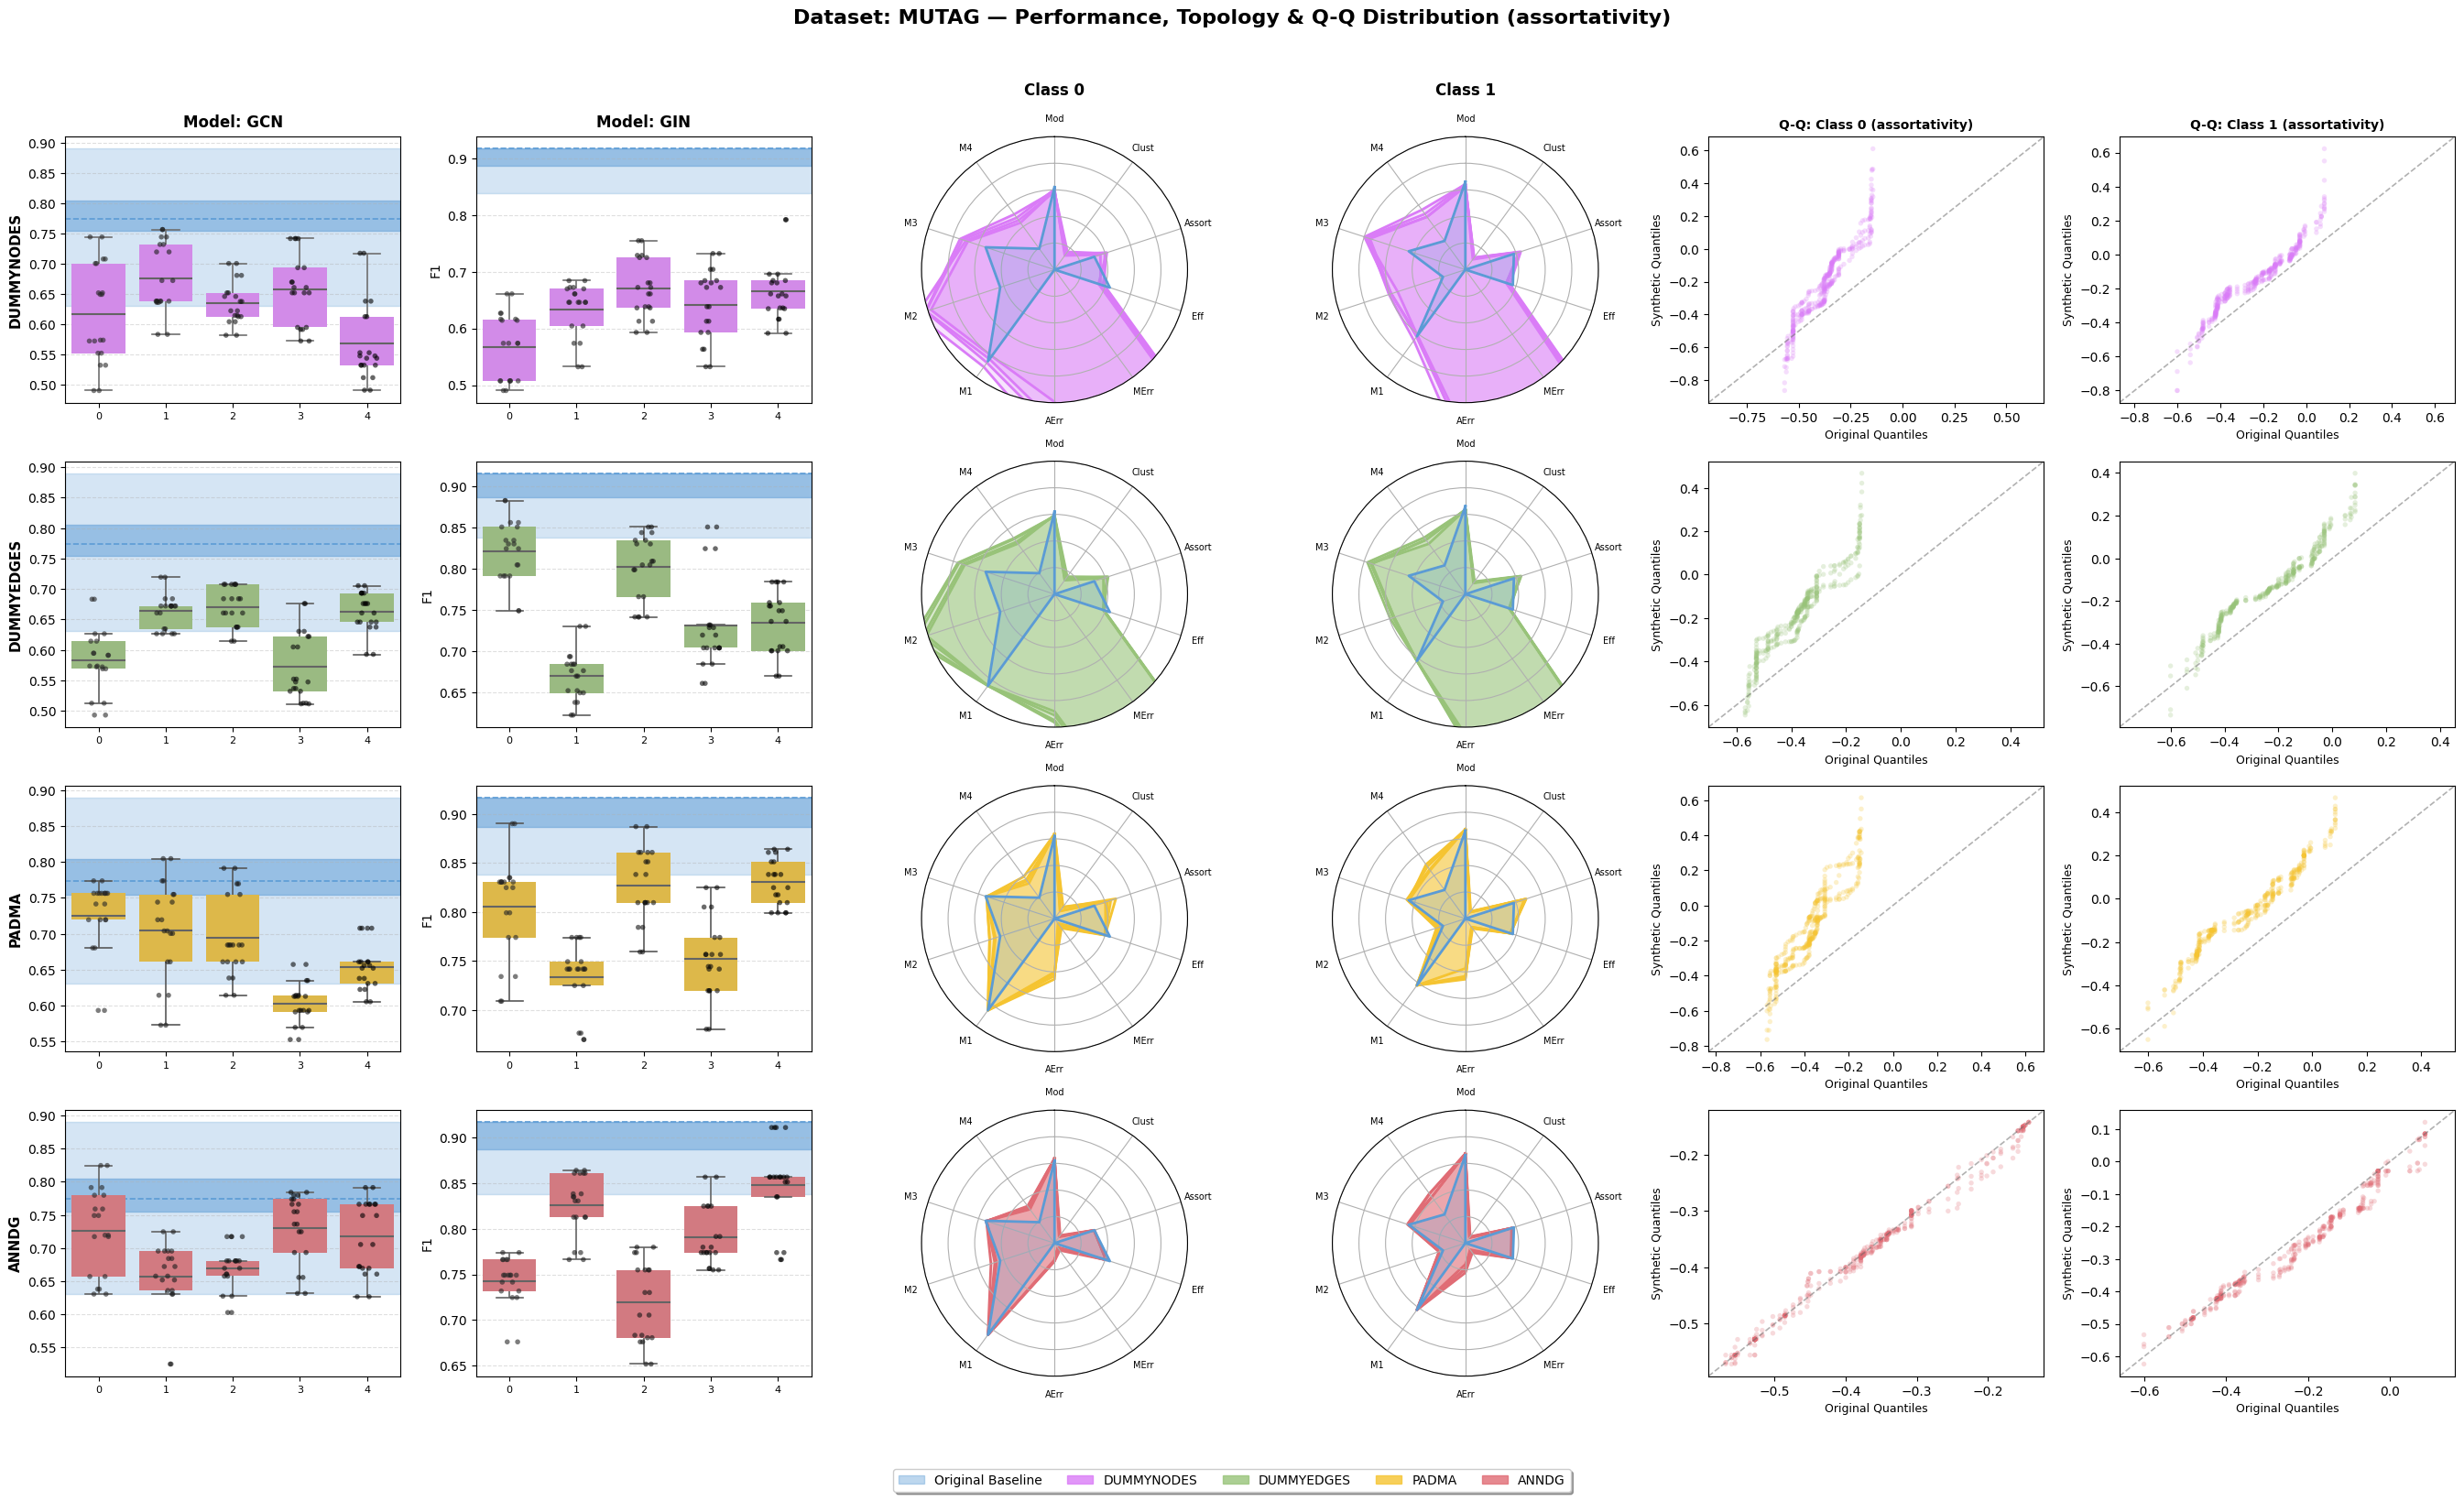

,Mod,Clust,Assort,Eff,MErr,AErr,M1,M2,M3,M4
Min Bound,-0.50,0.00,-1.00,0.00,0.00,0.00,0.00,0.00,-1.53,1.00
Max Bound,1.00,1.00,1.00,1.00,1.00,1.00,0.20,0.01,1.00,5.00


In [3]:
def compute_radar_bounds(df_pg_ds: pd.DataFrame, avg_v: float, avg_e: float) -> dict[str, tuple[float, float]]:
    """Computes mathematically robust bounds for radar plot metrics.

    Args:
        df_pg_ds: The DataFrame containing aggregated or raw per-graph stats.
        avg_v: Average number of nodes in the original dataset.
        avg_e: Average number of edges in the original dataset.
    Returns:
        A dictionary mapping each metric to its safe (min, max) boundaries.
    """
    bounds: dict[str, tuple[float, float]] = {"modularity": (-0.5, 1.0), "clustering": (0.0, 1.0), "assortativity": (-1.0, 1.0), "efficiency": (0.0, 1.0), "moments_error": (0.0, 1.0), "annd_error": (0.0, 1.0)}
        
    global_90 = df_pg_ds.quantile(0.9, numeric_only=True)
    global_min = df_pg_ds.min(numeric_only=True)
    
        # Moments 1 & 2: Bound at 0 and max empirical
    bounds["deg_moment_1"] = (0.0, float(global_90.get("deg_moment_1", 1.0)))
    bounds["deg_moment_2"] = (0.0, float(global_90.get("deg_moment_2", 1.0)))
    
    # Moment 3 (Skewness): Prevent zoom on near-zero variations using a priori bounds
    m3_min = min(-1.0, float(global_min.get("deg_moment_3", 0.0)))
    m3_max = max(1.0, float(global_90.get("deg_moment_3", 0.0)))
    bounds["deg_moment_3"] = (m3_min, m3_max)

    # Moment 4 (Kurtosis): Minimum theoretical is 1. Prevent zoom up to 10.
    m4_max = max(5.0, float(global_90.get("deg_moment_4", 0.0)))
    bounds["deg_moment_4"] = (1.0, m4_max)

    # Motifs: Use 90th percentile to avoid outlier-driven scaling
    for i in range(1, 9):
        col = f"motif_count_{i}"
        motif_max = max(1.0, float(global_90.get(col, 0.0)))
        bounds[col] = (0.0, motif_max)

    return bounds

def plot_performance_trajectory(df: pd.DataFrame, df_pg: pd.DataFrame, dataset: str, qq_metric: str = "modularity", variants_idx: list[int] | None = None, analyze_motifs: bool = True) -> None:
    """Plots GNN performance trajectories, topological radar profiles, and Q-Q plots"""
    if df_pg.empty: raise ValueError("Per-graph statistics DataFrame (df_pg) is empty.")
    if qq_metric not in df_pg.columns: raise ValueError(f"Metric '{qq_metric}' not found in df_pg columns.")

    methods = METHODS_PER_DATASET.get(dataset, [])
    df_dataset = df[df["dataset"] == dataset].copy()
    df_pg_ds = df_pg[df_pg["dataset"] == dataset].copy()

    if df_dataset.empty or df_pg_ds.empty or not methods: return

    topo_metrics = ["modularity", "clustering", "assortativity", "efficiency", "moments_error", "annd_error"]
    moment_metrics = [f"deg_moment_{i}" for i in range(1, 5)]
    motif_metrics = [f"motif_count_{i}" for i in range(1, 9)] if analyze_motifs else []
    all_metrics = topo_metrics + moment_metrics + motif_metrics
    
    # Aggregate raw metrics by (method, variant, label) using the mean.
    df_agg_raw = df_pg_ds.groupby(["source_base", "source", "label"], observed=True)[all_metrics].mean().reset_index()

    # Identifying bounds (Theoretical/Global) for robust scaling
    original_stats = df_pg_ds[df_pg_ds["source"] == "original"]
    avg_v = float(original_stats["n_nodes"].mean()) if "n_nodes" in original_stats.columns else 20.0
    avg_e = float(original_stats["n_edges"].mean()) if "n_edges" in original_stats.columns else 40.0
    radar_bounds = compute_radar_bounds(df_pg_ds, avg_v, avg_e)
    norm_bounds = {}
    scaled_cols = [f"scaled_{m}" for m in all_metrics]

    for m in all_metrics:
        min_val, max_val = radar_bounds[m]
        norm_bounds[m] = [f"{min_val:.2f}", f"{max_val:.2f}"]
        
        # Apply normalization with safety clipping
        denom = max_val - min_val
        df_agg_raw[f"scaled_{m}"] = ((df_agg_raw[m] - min_val) / denom if denom > 1e-9 else 0.0)

    df_agg_pg = df_agg_raw.set_index(["source_base", "source", "label"])

    # 2. Layout Setup (MODELS + Radar Classes + len(labels) Q-Q Plots)
    labels = sorted(df_pg_ds["label"].unique())
    n_total_cols = len(MODELS) + 2 * len(labels)
    n_rows = len(methods)

    fig = plt.figure(figsize=(4.5 * n_total_cols, 3.5 * n_rows + 1.2))
    gs = fig.add_gridspec(n_rows, n_total_cols)
    fig.suptitle(f"Dataset: {dataset} — Performance, Topology & Q-Q Distribution ({qq_metric})", fontsize=16, fontweight="bold", y=1.02)

    angles = np.linspace(0, 2 * np.pi, len(all_metrics), endpoint=False).tolist()
    angles += angles[:1]
    metric_labels = ["Mod", "Clust", "Assort", "Eff", "MErr", "AErr"] + [f"M{i}" for i in range(1, 5)]
    if analyze_motifs:
        metric_labels += [f"Motif{i}" for i in range(1, 9)]

    # Q-Q Shared Quantiles
    quantiles = np.linspace(0, 1, 100)
    global_min, global_max = df_pg_ds[qq_metric].min(), df_pg_ds[qq_metric].max()

    for row_idx, method in enumerate(methods):
        # --- Cartesian Performance Plots (Models) ---
        variant_sources = sorted([s for s in df_dataset["source"].unique() if s.startswith(f"{method}_")], key=lambda s: int(s.rsplit("_", 1)[-1]))
        x_pos = list(range(len(variant_sources)))
        v_pal = {s: PALETTE[method] for s in variant_sources}

        for col_idx, model in enumerate(MODELS):
            ax = fig.add_subplot(gs[row_idx, col_idx])
            
            # Baseline
            base_f1 = df_dataset.loc[(df_dataset["source"] == "original") & (df_dataset["model"] == model), "test_f1"]
            if not base_f1.empty:
                add_baseline_guide(ax, base_f1, color=PALETTE["original"], label="Original")

            # Trajectory
            plot_df = df_dataset.loc[df_dataset["source"].isin(variant_sources) & (df_dataset["model"] == model)].copy()
            if not plot_df.empty:
                plot_df["_xpos"] = plot_df["source"].map({s: p for s, p in zip(variant_sources, x_pos)})
                plot_performance_distribution(ax=ax, df=plot_df, x="_xpos", y="test_f1", hue="source", palette=v_pal, order=x_pos)

            if row_idx == 0: ax.set_title(f"Model: {model}", fontsize=12, fontweight="bold", pad=8)
            if col_idx == 0: ax.set_ylabel(method.upper(), fontsize=11, fontweight="bold")
            ax.set_xticks(x_pos)
            ax.set_xticklabels([s.rsplit("_", 1)[-1] for s in variant_sources], fontsize=8)
            ax.grid(axis="y", linestyle="--", alpha=0.4)

        # --- Polar Radar Plots (Classes) ---
        for label_idx, label in enumerate(labels):
            ax = fig.add_subplot(gs[row_idx, len(MODELS) + label_idx], projection="polar")
            
            # Baseline (Shared across all methods)
            try:
                base_vals = df_agg_pg.loc[("original", "original", label), scaled_cols].values.tolist()
                base_vals += base_vals[:1]
                ax.plot(angles, base_vals, color=PALETTE["original"], linewidth=2, zorder=3)
                ax.fill(angles, base_vals, color=PALETTE["original"], alpha=0.2, zorder=2)
            except KeyError: pass

            # Variants of current method
            for variant in variant_sources:
                v_idx = int(variant.rsplit("_", 1)[-1])
                if variants_idx is not None and v_idx not in variants_idx: continue
                try:
                    var_vals = df_agg_pg.loc[(method, variant, label), scaled_cols].values.tolist()
                    var_vals += var_vals[:1]
                    ax.plot(angles, var_vals, color=PALETTE[method], linewidth=2, zorder=1)
                    ax.fill(angles, var_vals, color=PALETTE[method], alpha=0.2, zorder=1)
                except KeyError: pass

            # Formatting
            ax.set_theta_offset(np.pi / 2)
            ax.set_theta_direction(-1)
            ax.set_thetagrids(np.degrees(angles[:-1]), metric_labels, fontsize=7)
            ax.set_ylim(0, 1)
            ax.set_yticklabels([])
            if row_idx == 0: ax.set_title(f"Class {label}", fontsize=12, fontweight="bold", pad=15)

        # --- Q-Q Plots (Original vs Selection of Synthetic Variants) ---
        for qq_idx in range(len(labels)):
            ax_qq = fig.add_subplot(gs[row_idx, len(MODELS) + len(labels) + qq_idx])
            lbl = labels[qq_idx]
            orig_vals = df_pg_ds[(df_pg_ds["source"] == "original") & (df_pg_ds["label"] == lbl)][qq_metric].values

            if len(orig_vals) > 0:
                orig_q = np.quantile(orig_vals, quantiles)
                all_synth_q = []
                
                for variant in variant_sources:
                    v_idx = int(variant.rsplit("_", 1)[-1])
                    if variants_idx is not None and v_idx not in variants_idx:
                        continue
                    synth_vals = df_pg_ds[(df_pg_ds["source"] == variant) & (df_pg_ds["label"] == lbl)][qq_metric].values
                    if len(synth_vals) > 0:
                        synth_q = np.quantile(synth_vals, quantiles)
                        all_synth_q.append(synth_q)
                        ax_qq.scatter(orig_q, synth_q, color=PALETTE[method], alpha=0.25, s=15, edgecolors="none")

                if all_synth_q:
                    flat_synth = np.concatenate(all_synth_q)
                    q_min, q_max = min(orig_q.min(), flat_synth.min()), max(orig_q.max(), flat_synth.max())
                    padding = (q_max - q_min) * 0.05 if q_max > q_min else 0.05
                    plot_lims = (q_min - padding, q_max + padding)

                    ax_qq.plot(plot_lims, plot_lims, color="#646464", linestyle="--", linewidth=1.2, alpha=0.5)
                    ax_qq.set_xlim(plot_lims); ax_qq.set_ylim(plot_lims)
                    ax_qq.set_xlabel("Original Quantiles", fontsize=9); ax_qq.set_ylabel("Synthetic Quantiles", fontsize=9)
                    if row_idx == 0: ax_qq.set_title(f"Q-Q: Class {lbl} ({qq_metric})", fontsize=10, fontweight="bold")
                else: ax_qq.text(0.5, 0.5, "No Synthetic Data", ha="center", va="center", alpha=0.5)
            else: ax_qq.text(0.5, 0.5, "No Original Data", ha="center", va="center", alpha=0.5)

    # Global Legend
    handles = [mpatches.Patch(color=PALETTE["original"], alpha=0.4, label="Original Baseline")]
    handles += [mpatches.Patch(color=PALETTE[m], alpha=0.8, label=m.upper()) for m in methods]
    fig.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, -0.05), ncol=1 + len(methods), frameon=True, shadow=True, fontsize=10)

    fig.tight_layout()
    plt.show()

    # Display Normalization Bounds
    df_bounds = pd.DataFrame(norm_bounds, index=["Min Bound", "Max Bound"])
    clean_cols = {"modularity": "Mod", "clustering": "Clust", "assortativity": "Assort", "efficiency": "Eff", "moments_error": "MErr", "annd_error": "AErr"}
    clean_cols.update({f"deg_moment_{i}": f"M{i}" for i in range(1, 5)})
    
    if analyze_motifs:
        clean_cols.update({f"motif_count_{i}": f"Motif{i}" for i in range(1, 9)})
    display(df_bounds.rename(columns=clean_cols))

def display_detailed_statistics_table(df_pg: pd.DataFrame, dataset: str, analyze_motifs: bool = True) -> None:
    df_pg_ds = df_pg[df_pg["dataset"] == dataset].copy()
    if df_pg_ds.empty: return

    acc_cols = [c for c in df_pg_ds.columns if c.startswith("mean_acc_")]
    topo_cols = [c for c in df_pg_ds.columns if c in ["modularity", "clustering", "assortativity", "efficiency", "moments_error", "annd_error"]]
    moment_cols = [c for c in df_pg_ds.columns if c.startswith("deg_moment_")]
    motif_cols = [c for c in df_pg_ds.columns if c.startswith("motif_count_")] if analyze_motifs else []
    all_metrics = acc_cols + topo_cols + moment_cols + motif_cols

    # Group by source, split, AND label (class)
    df_agg = df_pg_ds.groupby(["source", "split", "label"], observed=True)[all_metrics].mean()
    
    # Unstack label to columns: (original_metric, label)
    df_table = df_agg.unstack("label")

    cat_mapping, clean_names = {}, {}
    for cl in all_metrics:
        if cl in acc_cols:
            cat_mapping[cl], clean_names[cl] = "Accuracy", cl.replace("mean_acc_", "").upper()
        elif cl in topo_cols:
            cat_mapping[cl], clean_names[cl] = "Topology", "MErr" if cl == "moments_error" else "AErr" if cl == "annd_error" else cl.capitalize()
        elif cl in moment_cols:
            cat_mapping[cl], clean_names[cl] = "Moments", cl.replace("deg_moment_", "M")
        else:
            cat_mapping[cl], clean_names[cl] = "Motifs", cl.replace("motif_count_", "")

    # New MultiIndex Columns: (Category, Metric, Class)
    new_cols = []
    for orig_metric, label in df_table.columns:
        cat = cat_mapping[orig_metric]
        met = clean_names[orig_metric]
        cls = f"C{int(label)}"
        new_cols.append((cat, met, cls))
    
    df_table.columns = pd.MultiIndex.from_tuples(new_cols, names=["Category", "Metric", "Class"])

    def _src_key(s):
        if s == "original": return (0, 0)
        b, idx = s.rsplit("_", 1)
        return (BASE_METHOD_ORDER.index(b) + 1 if b in BASE_METHOD_ORDER else 99, int(idx))

    srcs = sorted(df_table.index.get_level_values("source").unique(), key=_src_key)
    splits = [sp for sp in ["Train", "Val", "Test"] if sp in df_table.index.get_level_values("split")]
    
    row_idx = [(s, sp) for s in srcs for sp in splits if (s, sp) in df_table.index]
    df_final = df_table.reindex(pd.MultiIndex.from_tuples(row_idx, names=["Method", "Split"]))

    cat_order = ["Accuracy", "Topology", "Moments"]
    if analyze_motifs: cat_order.append("Motifs")
    # Sort columns: Category -> Metric -> Class
    sorted_cols = sorted(df_final.columns, key=lambda x: (cat_order.index(x[0]), x[1], x[2]))
    df_final = df_final[sorted_cols]

    def _styler(styler):
        idx_col = 0
        for cat in cat_order:
            if cat in df_final.columns.levels[0]:
                n = len(df_final[cat].columns)
                if idx_col > 0: styler.set_table_styles([{"selector": f".col{idx_col}", "props": [("border-left", "2px solid #969696")]}], overwrite=False)
                idx_col += n

        methods = df_final.index.get_level_values("Method")
        for i in range(1, len(df_final)):
            if methods[i] != methods[i-1]:
                styler.set_table_styles([{"selector": f"tbody tr:nth-child({i+1})", "props": [("border-top", "2px solid #969696")]}], overwrite=False)

        styler.format("{:.3f}")
        styler.set_table_styles([
            {"selector": "th", "props": [("text-align", "center"), ("font-size", "10px")]},
            {"selector": "td", "props": [("text-align", "center"), ("font-size", "10px"), ("white-space", "nowrap")]}
        ], overwrite=False)
        styler.apply(lambda col: ["font-weight: bold" if methods[i] == "original" else "" for i in range(len(col))], axis=0)
        return styler

    display(_styler(df_final.style))

for ds in DATASETS:
    plot_performance_trajectory(df_raw, df_pg_raw, ds, qq_metric="assortativity", variants_idx=[1, 2, 3, 4, 5], analyze_motifs=False)
    # display_detailed_statistics_table(df_pg_raw, ds, analyze_motifs=True)

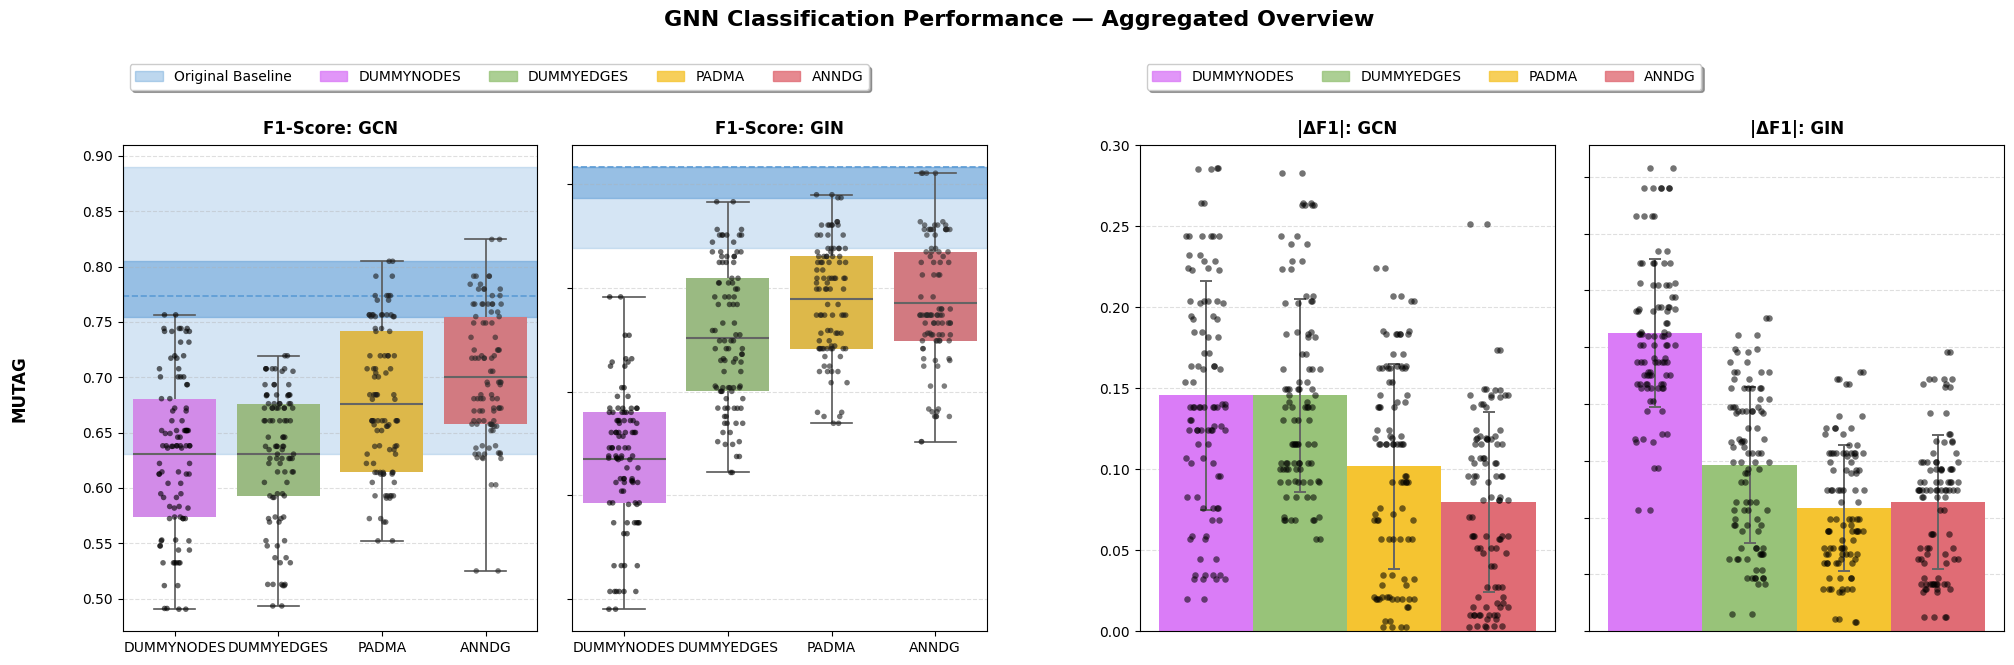

In [4]:
def compute_delta_df(df: pd.DataFrame) -> pd.DataFrame:
    baseline = df[df["source_base"] == "original"].groupby(["dataset", "model"])["test_f1"].mean()
    df_synth = df[df["source_base"] != "original"].copy()
    df_synth["delta_test_f1"] = df_synth.apply(lambda row: abs(row["test_f1"] - baseline.loc[(row["dataset"], row["model"])]), axis=1)
    return df_synth

df_synth = compute_delta_df(df_raw)

def plot_performance_overview(df: pd.DataFrame, df_synth: pd.DataFrame, analyze_motifs: bool = True) -> None:
    n_ds = len(DATASETS)
    fig, axes = plt.subplots(nrows=n_ds, ncols=5, figsize=(20, 5 * n_ds + 1.0), sharex=False, sharey=False, squeeze=False, gridspec_kw={'width_ratios': [1, 1, 0.2, 1, 1]})
    fig.suptitle("GNN Classification Performance — Aggregated Overview", fontsize=16, fontweight="bold", y=1.1)

    for r_idx, dataset in enumerate(DATASETS):
        df_ds = df[df["dataset"] == dataset]
        df_synth_ds = df_synth[df_synth["dataset"] == dataset]
        methods = METHODS_PER_DATASET.get(dataset, [])
        axes[r_idx, 2].set_visible(False)

        for c_idx, model in enumerate(MODELS):
            ax_box = axes[r_idx, c_idx]
            base_f1 = df_ds.loc[(df_ds["source"] == "original") & (df_ds["model"] == model), "test_f1"]
            if not base_f1.empty: add_baseline_guide(ax_box, base_f1, color=PALETTE["original"], label="Original")
            plot_df = df_ds[(df_ds["source_base"].isin(methods)) & (df_ds["model"] == model)].copy()
            if not plot_df.empty: plot_performance_distribution(ax_box, plot_df, x="source_base", y="test_f1", hue="source_base", palette={m: PALETTE[m] for m in methods}, order=methods)

            ax_box.set_xlabel("")
            ax_box.set_ylabel("")
            ax_box.set_xticks(range(len(methods)))
            ax_box.set_xticklabels([m.upper() for m in methods], fontsize=10)
            ax_box.grid(axis="y", linestyle="--", alpha=0.4)
            if c_idx == 1: ax_box.tick_params(labelleft=False)

            if r_idx == 0:
                ax_box.set_title(f"F1-Score: {model}", fontsize=12, fontweight="bold", pad=8)
                if c_idx == 0:
                    handles = [mpatches.Patch(color=PALETTE["original"], alpha=0.4, label="Original Baseline")] + [mpatches.Patch(color=PALETTE[m], alpha=0.8, label=m.upper()) for m in methods]
                    leg = ax_box.legend(handles=handles, loc="lower left", bbox_to_anchor=(0.0, 1.1), ncol=1 + len(methods), frameon=True, shadow=True, fontsize=10)
                    leg.set_in_layout(False)
            if c_idx == 0: ax_box.text(-0.25, 0.5, dataset, transform=ax_box.transAxes, fontsize=12, fontweight="bold", va="center", ha="center", rotation=90)

        delta_agg = df_synth_ds.groupby(["source_base", "model"], observed=True)["delta_test_f1"].agg(["mean", "std"])
        for c_idx, model in enumerate(MODELS):
            ax_bar = axes[r_idx, 3 + c_idx]
            bw = 0.6 / max(len(methods), 1)

            for m_idx, method in enumerate(methods):
                offset = (m_idx - (len(methods) - 1) / 2) * bw
                try: m_val, s_val = float(delta_agg.loc[(method, model), "mean"]), float(delta_agg.loc[(method, model), "std"])
                except (KeyError, TypeError): m_val, s_val = 0.0, 0.0

                ax_bar.bar(offset, m_val, width=bw, color=PALETTE[method], zorder=2)
                ax_bar.errorbar(offset, m_val, yerr=s_val, fmt="none", color="#646464", capsize=4, capthick=1.4, linewidth=1.4, zorder=3)
                
                run_deltas = df_synth_ds.loc[(df_synth_ds["source_base"] == method) & (df_synth_ds["model"] == model), "delta_test_f1"].to_numpy(dtype=np.float64)
                jitter = np.random.default_rng(42).uniform(-bw * 0.22, bw * 0.22, size=len(run_deltas))
                ax_bar.scatter(offset + jitter, run_deltas, color="black", alpha=0.55, s=22, zorder=4, linewidths=0)

            ax_bar.set_xticks([])
            ax_bar.set_ylim(bottom=0.0)
            ax_bar.grid(axis="y", linestyle="--", alpha=0.4)
            if c_idx == 1: ax_bar.tick_params(labelleft=False)

            if r_idx == 0:
                ax_bar.set_title(f"|ΔF1|: {model}", fontsize=12, fontweight="bold", pad=8)
                if c_idx == 0:
                    handles = [mpatches.Patch(color=PALETTE[m], alpha=0.8, label=m.upper()) for m in methods]
                    leg = ax_bar.legend(handles=handles, loc="lower left", bbox_to_anchor=(0.0, 1.1), ncol=len(methods), frameon=True, shadow=True, fontsize=10)
                    leg.set_in_layout(False)

    fig.tight_layout()
    plt.subplots_adjust(wspace=0.1)
    plt.show()

def _compute_aggregated_summary_df(df: pd.DataFrame, df_synth: pd.DataFrame, df_pg: pd.DataFrame, analyze_motifs: bool = True) -> pd.DataFrame:
    if df_pg.empty: return pd.DataFrame()

    f1_agg = df.groupby(["dataset", "source_base", "model"], observed=True)["test_f1"].agg(["mean", "std"])
    delta_agg = df_synth.groupby(["dataset", "source_base", "model"], observed=True)["delta_test_f1"].agg(["mean", "std"])
    
    topo_base = ["modularity", "clustering", "assortativity", "efficiency", "moments_error", "annd_error"]
    moment_metrics = sorted([c for c in df_pg.columns if c.startswith("deg_moment_")])
    motif_metrics = sorted([c for c in df_pg.columns if c.startswith("motif_count_")]) if analyze_motifs else []
    all_topo = topo_base + moment_metrics + motif_metrics
    topo_agg = df_pg.groupby(["dataset", "source_base"], observed=True)[all_topo].agg(["mean", "std"])
    
    all_methods = df["source_base"].cat.categories.tolist()
    
    c_tuples = []
    for model in MODELS: c_tuples.append(("F1-Score", model))
    for model in MODELS: c_tuples.append(("|Δ F1|", model))
    for m in topo_base: c_tuples.append(("Topology", "MErr" if m == "moments_error" else "AErr" if m == "annd_error" else m.capitalize()))
    for m in moment_metrics: c_tuples.append(("Moments", m.replace("deg_moment_", "M")))
    if analyze_motifs:
        for m in motif_metrics: c_tuples.append(("Motifs", m.replace("motif_count_", "")))
    
    rows, r_tuples = [], []
    for ds in DATASETS:
        for m in all_methods:
            if m != "original" and m not in METHODS_PER_DATASET.get(ds, []): continue
            
            r_tuples.append((ds, m.upper()))
            row = []
            idx = (ds, m)

            for model in MODELS:
                try: row.append(f"{f1_agg.loc[idx+(model,), 'mean']:.3f} ± {f1_agg.loc[idx+(model,), 'std']:.3f}")
                except KeyError: row.append("N/A")

            for model in MODELS:
                if m == "original": row.append("-")
                else:
                    try: row.append(f"{delta_agg.loc[idx+(model,), 'mean']:.3f} ± {delta_agg.loc[idx+(model,), 'std']:.3f}")
                    except KeyError: row.append("N/A")
            
            for tm in all_topo:
                try: row.append(f"{topo_agg.loc[idx, (tm, 'mean')]:.3f} ± {topo_agg.loc[idx, (tm, 'std')]:.3f}")
                except KeyError: row.append("N/A")
            rows.append(row)

    return pd.DataFrame(rows, index=pd.MultiIndex.from_tuples(r_tuples, names=["Dataset", "Method"]), columns=pd.MultiIndex.from_tuples(c_tuples, names=["Category", "Metric"]))

def display_aggregated_summary(df: pd.DataFrame, df_synth: pd.DataFrame, df_pg: pd.DataFrame, analyze_motifs: bool = True) -> None:
    df_res = _compute_aggregated_summary_df(df, df_synth, df_pg, analyze_motifs)
    if df_res.empty: return

    def _styler(styler):
        c_tuples = df_res.columns.tolist()
        categories = [c[0] for c in c_tuples]
        for i in range(1, len(categories)):
            if categories[i] != categories[i-1]:
                styler.set_table_styles([{"selector": f".col{i}", "props": [("border-left", "2px solid #969696")]}], overwrite=False)
        
        idx_lvl = df_res.index.get_level_values(0)
        for i in range(1, len(df_res)):
            if idx_lvl[i] != idx_lvl[i-1]:
                styler.set_table_styles([{"selector": f"tbody tr:nth-child({i+1})", "props": [("border-top", "2px solid #969696")]}], overwrite=False)
        
        styler.set_table_styles([{"selector": "th", "props": [("text-align", "center"), ("font-size", "10px")]}, {"selector": "td", "props": [("text-align", "center"), ("font-size", "10px")]}], overwrite=False)
        methods = df_res.index.get_level_values(1)
        styler.apply(lambda c: ["font-weight: bold" if methods[i] == "ORIGINAL" else "" for i in range(len(c))], axis=0)
        return styler

    display(_styler(df_res.style))

plot_performance_overview(df_raw, df_synth, analyze_motifs=True)
display_aggregated_summary(df_raw, df_synth, df_pg_raw, analyze_motifs=True)

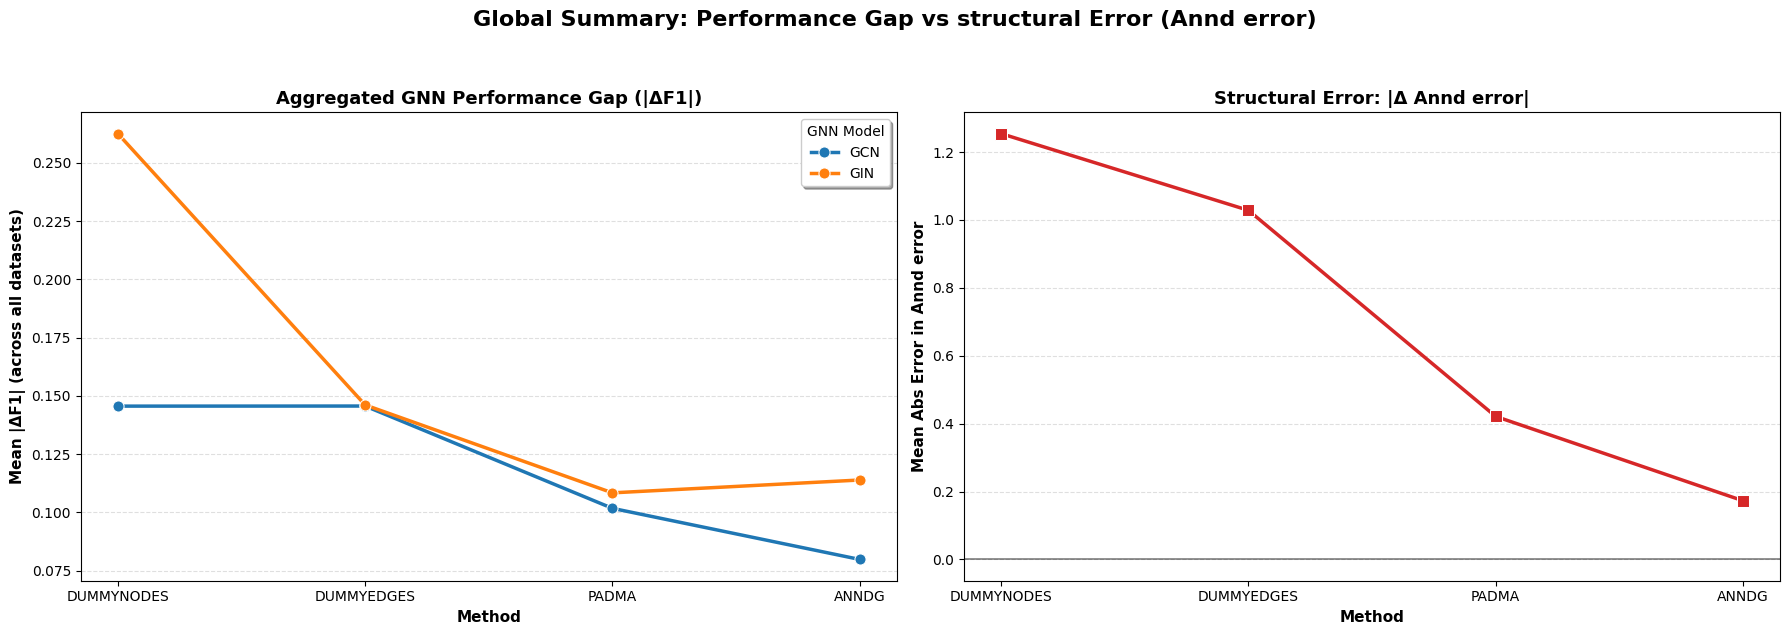

In [5]:
def plot_final_results_comparison(df_synth: pd.DataFrame, df_pg: pd.DataFrame, analyze_metric: str = "modularity") -> None:
    """
    Plots a dual-panel summary:
    1. Left: Aggregated mean Absolute F1-Delta (|ΔF1|) across datasets.
    2. Right: Mean Absolute Error (MAE) for a selected topological metric relative to original baselines.
    """
    if df_synth.empty or df_pg.empty:
        print("Required data is missing for aggregated plots.")
        return

    # 1. Data Preparation
    # Performance data
    df_perf = df_synth[df_synth["source_base"] != "original"].copy()
    df_perf["source_base"] = df_perf["source_base"].cat.remove_unused_categories()
    
    # Topological data error calculation
    df_topo = df_pg[df_pg["source_base"] != "original"].copy()
    df_topo["source_base"] = df_topo["source_base"].cat.remove_unused_categories()
    
    # Store original metrics per dataset and graph_idx
    original_metrics = {}
    for (d_name, g_idx), grp in df_pg[df_pg["source"] == "original"].groupby(["dataset", "graph_idx"]):
        original_metrics[(d_name, g_idx)] = grp[analyze_metric].mean()
    
    # Compute Absolute Error for each synthetic graph compared to its specific matching original graph
    df_topo[f"abs_err_{analyze_metric}"] = df_topo.apply(
        lambda row: abs(row[analyze_metric] - original_metrics.get((row["dataset"], row.get("graph_idx")), np.nan)), axis=1
    )

    # 2. Plotting
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    metric_label = analyze_metric.replace("_", " ").capitalize()
    fig.suptitle(f"Global Summary: Performance Gap vs structural Error ({metric_label})", fontsize=16, fontweight="bold", y=1.05)

    # --- Left: Performance Gap (|ΔF1|) ---
    sns.lineplot(
        data=df_perf, 
        x="source_base", 
        y="delta_test_f1", 
        hue="model", 
        marker="o", 
        markersize=8, 
        linewidth=2.5,
        ax=axes[0],
        # errorbar=("ci", 95)
        errorbar=None
    )
    axes[0].set_title("Aggregated GNN Performance Gap (|ΔF1|)", fontsize=13, fontweight="bold")
    axes[0].set_xlabel("Method", fontsize=11, fontweight="bold")
    axes[0].set_ylabel("Mean |ΔF1| (across all datasets)", fontsize=11, fontweight="bold")
    axes[0].grid(axis='y', linestyle='--', alpha=0.4)
    axes[0].legend(title="GNN Model", frameon=True, shadow=True)

    # --- Right: Topological Metric Error Trend ---
    sns.lineplot(
        data=df_topo, 
        x="source_base", 
        y=f"abs_err_{analyze_metric}", 
        marker="s", 
        markersize=8, 
        linewidth=2.5, 
        color="#D62728", # Distinctive red for structure error
        ax=axes[1],
        # errorbar=("ci", 95)
        errorbar=None
    )
    
    axes[1].axhline(0, color="black", linestyle="-", linewidth=1.2, alpha=0.5) # Reference for zero error
    axes[1].set_title(f"Structural Error: |Δ {metric_label}|", fontsize=13, fontweight="bold")
    axes[1].set_xlabel("Method", fontsize=11, fontweight="bold")
    axes[1].set_ylabel(f"Mean Abs Error in {metric_label}", fontsize=11, fontweight="bold")
    axes[1].grid(axis='y', linestyle='--', alpha=0.4)

    # Common formatting
    for ax in axes:
        methods = [m.upper() for m in df_perf["source_base"].cat.categories]
        ax.set_xticks(ticks=range(len(methods)), labels=methods)

    plt.tight_layout()
    plt.show()

# Run final summary analysis
plot_final_results_comparison(df_synth, df_pg_raw, analyze_metric="annd_error")

In [6]:
# import numpy as np
# import matplotlib.pyplot as plt
# from scipy.interpolate import splrep, splev

# # ==========================================
# # 1. INIZIO SEGNALE (Simulazione dati)
# # ==========================================
# # Simuliamo i gradi k: molto ravvicinati all'inizio, molto sparsi alla fine
# k = np.unique(np.geomspace(1, 20, 10).astype(int))

# # Simuliamo il grado medio dei vicini knn(k)
# # In molti grafi reali segue una legge di potenza, aggiungiamo rumore per renderlo realistico
# knn_reale = 2 * k**(-0.4) 
# rumore = np.random.normal(0, knn_reale * 0.25)
# knn = np.maximum(knn_reale + rumore, 1) # Evitiamo valori negativi o zero

# print(f"--> Lunghezza segnale originale: {len(k)} campioni")

# # ==========================================
# # 2. COMPRESSIONE CON LOG
# # ==========================================
# log_k = np.log(k)
# log_knn = np.log(knn)

# # ==========================================
# # 3. NORMALIZZAZIONE
# # ==========================================
# # Portiamo l'asse x (log_k) in un intervallo standard [0, 1].
# # Questo rende la codifica indipendente dal grado massimo del grafo.
# x_min, x_max = log_k.min(), log_k.max()
# x_norm = (log_k - x_min) / (x_max - x_min)

# # ==========================================
# # 4. CODIFICA (Fitting B-Spline Dinamico)
# # ==========================================

# N_punti = len(log_k)
# grado_spline = 3   # Spline cubica

# # La regola d'oro: K_desiderati deve essere rigorosamente minore di N_punti.
# # Impostiamo un massimo di 15, ma se i punti sono meno, riduciamo K in automatico.
# K_desiderati = min(15, N_punti - 2)

# # Controllo di sicurezza estremo: se il grafo è microscopico (es. 4 punti)
# # dobbiamo abbassare anche il grado della spline (non puoi fare una cubica con 3 punti).
# if K_desiderati <= grado_spline:
#     grado_spline = max(1, K_desiderati - 1)
#     print(f"⚠️ Grafo piccolissimo: Grado della spline ridotto a {grado_spline}")

# # Calcolo nodi interni
# num_nodi_interni = K_desiderati - grado_spline - 1

# if num_nodi_interni > 0:
#     nodi_interni = np.linspace(0, 1, num_nodi_interni + 2)[1:-1]
#     tck = splrep(x_norm, log_knn, k=grado_spline, t=nodi_interni, task=-1)
# else:
#     # Se non ci sono nodi interni (perché K è bassissimo), usiamo splrep normale
#     # chiedendo semplicemente una curva polinomiale liscia senza nodi interni.
#     tck = splrep(x_norm, log_knn, k=grado_spline, s=0.5)

# coefficienti = tck[1]
# coefficienti_utili = coefficienti[coefficienti != 0]

# print(f"--> Punti dati disponibili: {N_punti}")
# print(f"--> Segnale compresso in ESATTAMENTE: {len(coefficienti_utili)} coefficienti")
# # ==========================================
# # DECODIFICA (Torniamo al segnale originale)
# # ==========================================
# # Creiamo un asse continuo super denso per la ricostruzione
# x_continuo = np.linspace(0, 1, 300)

# # Valutiamo la spline usando i coefficienti
# log_knn_pred = splev(x_continuo, tck)

# # Invertiamo logaritmo e normalizzazione
# k_pred = np.exp(x_continuo * (x_max - x_min) + x_min)
# knn_pred = np.exp(log_knn_pred)

# # ==========================================
# # VISUALIZZAZIONE DEI 4 STEP
# # ==========================================
# fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# # Step 1: Segnale Originale
# axs[0, 0].scatter(k, knn, c='blue', s=30, alpha=0.7)
# axs[0, 0].set_title('1. Inizio Segnale Originale\n(Denso a sinistra, sparso a destra)')
# axs[0, 0].set_xlabel('Grado k'); axs[0, 0].set_ylabel('knn(k)')
# axs[0, 0].grid(True, linestyle='--', alpha=0.5)

# # Step 2: Spazio Log-Log
# axs[0, 1].scatter(log_k, log_knn, c='orange', s=30, alpha=0.7)
# axs[0, 1].set_title('2. Compressione con Log-Log\n(Le distanze si normalizzano)')
# axs[0, 1].set_xlabel('log(k)'); axs[0, 1].set_ylabel('log(knn)')
# axs[0, 1].grid(True, linestyle='--', alpha=0.5)

# # Step 3: Normalizzazione
# axs[1, 0].scatter(x_norm, log_knn, c='green', s=30, alpha=0.7)
# axs[1, 0].set_title('3. Normalizzazione Asse X [0, 1]\n(Pronto per la B-Spline)')
# axs[1, 0].set_xlabel('x normalizzato'); axs[1, 0].set_ylabel('log(knn)')
# axs[1, 0].grid(True, linestyle='--', alpha=0.5)

# # Step 4: Ricostruzione Spline
# axs[1, 1].scatter(k, knn, c='blue', s=30, alpha=0.3, label='Punti originali')
# axs[1, 1].plot(k_pred, knn_pred, c='red', linewidth=3, 
#                label=f'Curva decodificata\n(da {len(coefficienti_utili)} coefficienti)')
# axs[1, 1].set_title('4. Interpolazione e Ritorno\n(Risultato finale decodificato)')
# axs[1, 1].set_xlabel('Grado k'); axs[1, 1].set_ylabel('knn(k)')
# axs[1, 1].legend()
# axs[1, 1].grid(True, linestyle='--', alpha=0.5)

# plt.tight_layout()
# plt.show()